In [1]:
import pandas as pd, anndata as ad, scanpy as sc, numpy as np, matplotlib.pyplot as plt
import scipy.sparse as sp

In [2]:
adata = sc.read_h5ad("micro_mouse_rna.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 40553 × 32285
    obs: 'library_id', 'index', 'orig.ident.x', 'nCount_RNA', 'nFeature_RNA', 'scrubDoublets', 'doublet_scores_obs', 'cell_barcode', 'qc_pass', 'percent.mt', 'tsse', 'frac_dup', 'n_fragment', 'frac_mito', 'doublet_score', 'leverage.score', 'seurat_clusters', 'cluster_full', 'cluster_full.score', 'predicted_allen_class', 'predicted_allen_subclass', 'leverage.score.1', 'subclass', 'neurotransmitter', 'class', 'Senescence_score1', 'group', 'nCount_RNA.trans', 'nFeature_RNA.trans', 'hAPP', 'hPSEN1', 'final_cluster', 'final_celltype', 'final_cluster_color', 'final_celltype_color', 'final_group', 'mouse_id', 'genotype', 'sex', 'age', 'intervention'

(array([3.3932e+04, 3.9940e+03, 1.4910e+03, 7.7700e+02, 2.5000e+02,
        6.8000e+01, 2.5000e+01, 8.0000e+00, 4.0000e+00, 4.0000e+00]),
 array([ 565. , 1188.9, 1812.8, 2436.7, 3060.6, 3684.5, 4308.4, 4932.3,
        5556.2, 6180.1, 6804. ]),
 <BarContainer object of 10 artists>)

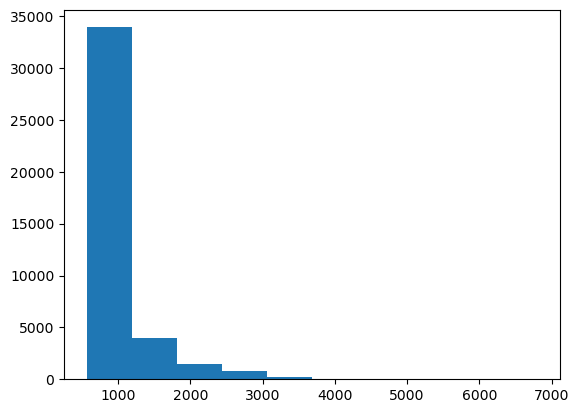

In [4]:
plt.hist(adata.obs["nCount_RNA"])

(array([2.9353e+04, 6.5910e+03, 2.0370e+03, 1.3770e+03, 7.8800e+02,
        2.7500e+02, 8.3000e+01, 3.3000e+01, 1.0000e+01, 6.0000e+00]),
 array([ 501. ,  738.3,  975.6, 1212.9, 1450.2, 1687.5, 1924.8, 2162.1,
        2399.4, 2636.7, 2874. ]),
 <BarContainer object of 10 artists>)

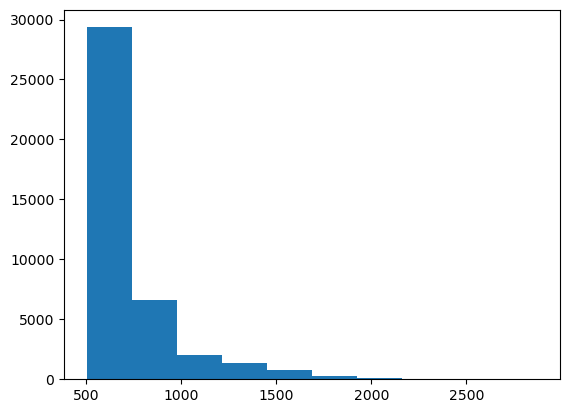

In [5]:
plt.hist(adata.obs["nFeature_RNA"])

In [6]:
np.unique(adata.obs["final_celltype"])

array(['Micro'], dtype=object)

In [7]:
np.unique(adata.obs["mouse_id"])

array(['10C', '11C', '12C', '15C', '16C', '17C', '21C', '22C', '23C',
       '24C', '3C', '4C', '5C', '6C', '9C', 'SG_AD_10C', 'SG_AD_11C',
       'SG_AD_12C', 'SG_AD_16C', 'SG_AD_17C', 'SG_AD_18C', 'SG_AD_22C',
       'SG_AD_23C', 'SG_AD_24C', 'SG_AD_28C', 'SG_AD_29C', 'SG_AD_30C',
       'SG_AD_34C', 'SG_AD_35C', 'SG_AD_36C', 'SG_AD_40C', 'SG_AD_41C',
       'SG_AD_42C', 'SG_AD_46C', 'SG_AD_47C', 'SG_AD_48C', 'SG_AD_4C',
       'SG_AD_5C', 'SG_AD_6C', 'SL10B', 'SL11B', 'SL12B', 'SL13B',
       'SL14B', 'SL15B', 'SL16B', 'SL17B', 'SL18B', 'SL19B', 'SL1B',
       'SL22B', 'SL23B', 'SL24B', 'SL25B', 'SL26B', 'SL27B', 'SL28B',
       'SL29B', 'SL2B', 'SL30B', 'SL31B', 'SL32B', 'SL33B', 'SL34B',
       'SL35B', 'SL36B', 'SL37B', 'SL38B', 'SL39B', 'SL3B', 'SL40B',
       'SL41B', 'SL42B', 'SL43B', 'SL45B', 'SL46B', 'SL47B', 'SL48B',
       'SL49B', 'SL4B', 'SL5B', 'SL6B', 'SL9B', 'xx10B', 'xx12B', 'xx13B',
       'xx15B', 'xx16B', 'xx18B', 'xx19B', 'xx1B', 'xx21B', 'xx22B',
       'xx24B',

In [8]:
np.unique(adata.obs["genotype"])

array(['5XFAD', 'WT'], dtype=object)

In [9]:
np.unique(adata.obs["sex"])

array(['F', 'M'], dtype=object)

In [10]:
np.unique(adata.obs["age"])

array(['18M', '3M', '9M'], dtype=object)

In [11]:
np.unique(adata.obs["intervention"])

array(['Ex', 'Sed', 'na'], dtype=object)

In [13]:
adata.obs["age"] = adata.obs["age"].astype("str")
adata.obs["genotype"] = adata.obs["genotype"].astype("str")

In [18]:
mask = (
    ((adata.obs["age"] == "3M") & (adata.obs["genotype"] == "WT")) |
    ((adata.obs["age"] == "18M") & (adata.obs["genotype"] == "5XFAD"))
)

adata_sub = adata[mask].copy()

In [19]:
adata_sub

AnnData object with n_obs × n_vars = 17154 × 32285
    obs: 'library_id', 'index', 'orig.ident.x', 'nCount_RNA', 'nFeature_RNA', 'scrubDoublets', 'doublet_scores_obs', 'cell_barcode', 'qc_pass', 'percent.mt', 'tsse', 'frac_dup', 'n_fragment', 'frac_mito', 'doublet_score', 'leverage.score', 'seurat_clusters', 'cluster_full', 'cluster_full.score', 'predicted_allen_class', 'predicted_allen_subclass', 'leverage.score.1', 'subclass', 'neurotransmitter', 'class', 'Senescence_score1', 'group', 'nCount_RNA.trans', 'nFeature_RNA.trans', 'hAPP', 'hPSEN1', 'final_cluster', 'final_celltype', 'final_cluster_color', 'final_celltype_color', 'final_group', 'mouse_id', 'genotype', 'sex', 'age', 'intervention'

In [43]:
np.unique(adata_sub.obs["age"])

array(['18M', '3M'], dtype=object)

Original human set has 9964 cells, 5758 are left for ML training, ~58% retain rate

### Precompute embedding

In [33]:
adata_sub_flt = adata_sub.copy()

In [34]:
def preprocess(adata, n_pcs,*, donor_key="orig.ident", mito_key = "percent.mito", 
               ct_flt = "nCount_RNA", min_donor_frac=0.5, min_per_donor=0.01):
    mito_keep = adata.obs[mito_key] <= 20
    adata._inplace_subset_obs(mito_keep)
    if not np.issubdtype(adata.X.dtype, np.floating): adata.X = adata.X.astype(np.float32)
    
    u = adata.obs[ct_flt].astype(float)  # or "total_counts" if that's your column
    thr = max(u.quantile(0.999), 3*u.median())
    thr  # ← this single number is the “pretty-sure” doublet UMI cutoff

    sc.pp.filter_cells(adata, min_genes=600)
    sc.pp.filter_cells(adata, max_counts = thr)
    sc.pp.filter_genes(adata, min_cells = int(0.01 * adata.n_obs))

    donors = adata.obs[donor_key].to_numpy(); U, inv = np.unique(donors, return_inverse=True)
    X = adata.X.tocsr() if sp.issparse(adata.X) else sp.csr_matrix(adata.X)
    X_bin = X.copy(); X_bin.data[:] = 1
    pdp = np.vstack([(X_bin[inv==i].sum(axis=0).A1) / max(1, (inv==i).sum()) for i in range(len(U))]) if len(U) else np.zeros((0, X.shape[1]))
    keep = (pdp >= min_per_donor).mean(0) > min_donor_frac
    adata._inplace_subset_var(keep)

    sc.pp.normalize_total(adata, target_sum=1e4); sc.pp.log1p(adata);
    sc.pp.pca(adata, n_comps=n_pcs)

    return adata

In [35]:
result_dir = "./"
ct_flt = "nCount_RNA"
n_pcs = 30
mito_key = "percent.mt"
donor_key = "mouse_id"

In [36]:
adata_sub_flt = preprocess(adata_sub_flt, n_pcs, donor_key = donor_key, mito_key = mito_key, ct_flt = ct_flt)

In [37]:
adata_sub_flt

AnnData object with n_obs × n_vars = 9945 × 9130
    obs: 'library_id', 'index', 'orig.ident.x', 'nCount_RNA', 'nFeature_RNA', 'scrubDoublets', 'doublet_scores_obs', 'cell_barcode', 'qc_pass', 'percent.mt', 'tsse', 'frac_dup', 'n_fragment', 'frac_mito', 'doublet_score', 'leverage.score', 'seurat_clusters', 'cluster_full', 'cluster_full.score', 'predicted_allen_class', 'predicted_allen_subclass', 'leverage.score.1', 'subclass', 'neurotransmitter', 'class', 'Senescence_score1', 'group', 'nCount_RNA.trans', 'nFeature_RNA.trans', 'hAPP', 'hPSEN1', 'final_cluster', 'final_celltype', 'final_cluster_color', 'final_celltype_color', 'final_group', 'mouse_id', 'genotype', 'sex', 'age', 'intervention', 'n_genes', 'n_counts'
    var: 'n_cells'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [38]:
np.unique(adata_sub_flt.obs["mouse_id"], return_counts = True)

(array(['15C', '16C', '17C', '3C', '5C', '6C', 'SL10B', 'SL11B', 'SL12B',
        'SL13B', 'SL14B', 'SL22B', 'SL23B', 'SL25B', 'SL26B', 'SL33B',
        'SL34B', 'SL35B', 'SL36B', 'SL37B', 'SL38B', 'SL45B', 'SL46B',
        'SL47B', 'SL48B', 'SL49B', 'SL9B'], dtype=object),
 array([ 275,   20,   72,  276,  115,    3,   55,  113,  519,  523,  104,
         336,  460, 1023,  950,  372,   45,   76,  584,  387,  209,  335,
         523,  252,  884, 1330,  104]))

In [39]:
np.unique(adata_sub_flt.obs["age"], return_counts = True)

(array(['18M', '3M'], dtype=object), array([9184,  761]))

In [57]:
pd.crosstab(adata_sub_flt.obs["age"], adata_sub_flt.obs["genotype"])

genotype,5XFAD,WT
age,,
3M,0,761
18M,9184,0


In [59]:
pd.crosstab(adata_sub_flt.obs["mouse_id"], adata_sub_flt.obs["age"])

age,3M,18M
mouse_id,,
3C,276,0
5C,115,0
6C,3,0
15C,275,0
16C,20,0
17C,72,0
SL9B,0,104
SL10B,0,55
SL11B,0,113


In [60]:
keep_names = ["SL47B", "SL10B", "SL11B", "SL14B", "SL38B", "SL26B"] 
# 646 train + val cells for control
# 733 train + val cells for AD, balance dataset

In [65]:
mask = (adata_sub_flt.obs["genotype"] != "5XFAD") | adata_sub_flt.obs["mouse_id"].isin(keep_names)

adata_sub_flt_balanced = adata_sub_flt[mask].copy()

In [66]:
adata_sub_flt_balanced

AnnData object with n_obs × n_vars = 2444 × 9130
    obs: 'library_id', 'index', 'orig.ident.x', 'nCount_RNA', 'nFeature_RNA', 'scrubDoublets', 'doublet_scores_obs', 'cell_barcode', 'qc_pass', 'percent.mt', 'tsse', 'frac_dup', 'n_fragment', 'frac_mito', 'doublet_score', 'leverage.score', 'seurat_clusters', 'cluster_full', 'cluster_full.score', 'predicted_allen_class', 'predicted_allen_subclass', 'leverage.score.1', 'subclass', 'neurotransmitter', 'class', 'Senescence_score1', 'group', 'nCount_RNA.trans', 'nFeature_RNA.trans', 'hAPP', 'hPSEN1', 'final_cluster', 'final_celltype', 'final_cluster_color', 'final_celltype_color', 'final_group', 'mouse_id', 'genotype', 'sex', 'age', 'intervention', 'n_genes', 'n_counts'
    var: 'n_cells'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [67]:
adata_sub_flt_balanced.write_h5ad("micro_mouse_rna_training_v3_precomp_balanced.h5ad")

**Form the test set: same genes, same cell filters**

In [50]:
adata_sub_test = adata.copy()

In [51]:
np.max(adata_sub_test.obs["percent.mt"])

np.float64(9.79938271604938)

In [52]:
def preprocess_test(adata, keep_feat, n_pcs,*, donor_key="orig.ident", ct_flt = "nCount_RNA"):
    if not np.issubdtype(adata.X.dtype, np.floating): adata.X = adata.X.astype(np.float32)
    
    u = adata.obs[ct_flt].astype(float)  # or "total_counts" if that's your column
    thr = max(u.quantile(0.999), 3*u.median())

    sc.pp.filter_cells(adata, min_genes=600)
    sc.pp.filter_cells(adata, max_counts = thr)
    adata._inplace_subset_var(keep_feat)

    sc.pp.normalize_total(adata, target_sum=1e4); sc.pp.log1p(adata);
    sc.pp.pca(adata, n_comps=n_pcs)

    return adata

In [53]:
result_dir = "./"
ct_flt = "nCount_RNA"
n_pcs = 30
mito_key = "percent.mt"
donor_key = "mouse_id"

In [54]:
adata_sub_test = preprocess_test(adata_sub_test, adata_sub_flt.var_names, n_pcs, donor_key=donor_key, ct_flt = ct_flt)

In [55]:
adata_sub_test

AnnData object with n_obs × n_vars = 23720 × 9130
    obs: 'library_id', 'index', 'orig.ident.x', 'nCount_RNA', 'nFeature_RNA', 'scrubDoublets', 'doublet_scores_obs', 'cell_barcode', 'qc_pass', 'percent.mt', 'tsse', 'frac_dup', 'n_fragment', 'frac_mito', 'doublet_score', 'leverage.score', 'seurat_clusters', 'cluster_full', 'cluster_full.score', 'predicted_allen_class', 'predicted_allen_subclass', 'leverage.score.1', 'subclass', 'neurotransmitter', 'class', 'Senescence_score1', 'group', 'nCount_RNA.trans', 'nFeature_RNA.trans', 'hAPP', 'hPSEN1', 'final_cluster', 'final_celltype', 'final_cluster_color', 'final_celltype_color', 'final_group', 'mouse_id', 'genotype', 'sex', 'age', 'intervention', 'n_genes', 'n_counts'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [56]:
adata_sub_test.write_h5ad("micro_mouse_rna_testing_v3_precomp.h5ad")

**Examining human data**

In [7]:
adata_human_flt = sc.read_h5ad("../combined_analysis/adata_objects/microglia_mgh_rna_v3_precomp.h5ad")

In [8]:
adata_human_flt

AnnData object with n_obs × n_vars = 5758 × 12809
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'percent.ribo', 'percent.hemo', 'doublet.filter', 'Jorstard.pred', 'harmony_clusters', 'seurat_clusters', 'remove_or_not', 'unintegrated_clusters', 'AD', 'Subclass', 'Subclass_fct', 'class', 'brain.region', 'barcode', 'nCount_ATAC', 'nFeature_ATAC', 'n_counts', 'n_genes'
    var: 'n_counts', 'n_cells'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

(array([3195., 1453.,  574.,  267.,  138.,   68.,   28.,   19.,    9.,
           7.]),
 array([ 1320.,  2939.,  4558.,  6177.,  7796.,  9415., 11034., 12653.,
        14272., 15891., 17510.]),
 <BarContainer object of 10 artists>)

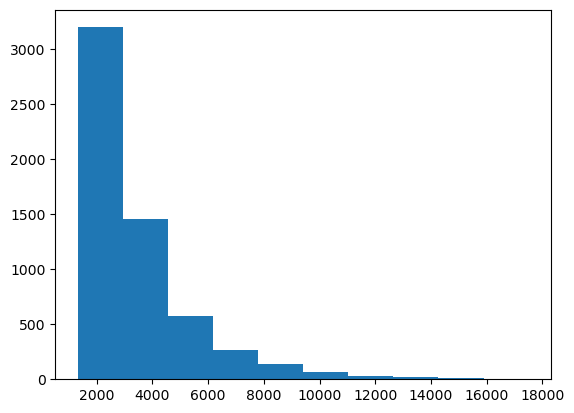

In [9]:
plt.hist(adata_human_flt.obs["nCount_RNA"])

(array([2506., 1651.,  825.,  415.,  204.,   85.,   35.,   23.,   10.,
           4.]),
 array([1000. , 1469.9, 1939.8, 2409.7, 2879.6, 3349.5, 3819.4, 4289.3,
        4759.2, 5229.1, 5699. ]),
 <BarContainer object of 10 artists>)

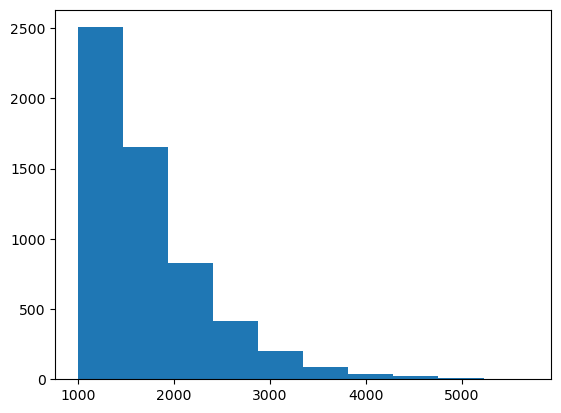

In [10]:
plt.hist(adata_human_flt.obs["nFeature_RNA"])

### Inspect processed objects

In [2]:
adata_train = sc.read_h5ad("train.h5ad")
adata_test = sc.read_h5ad("test.h5ad")

In [3]:
adata_train

AnnData object with n_obs × n_vars = 17154 × 9208
    obs: 'library_id', 'index', 'orig.ident.x', 'nCount_RNA', 'nFeature_RNA', 'scrubDoublets', 'doublet_scores_obs', 'cell_barcode', 'qc_pass', 'percent.mt', 'tsse', 'frac_dup', 'n_fragment', 'frac_mito', 'doublet_score', 'leverage.score', 'seurat_clusters', 'cluster_full', 'cluster_full.score', 'predicted_allen_class', 'predicted_allen_subclass', 'leverage.score.1', 'subclass', 'neurotransmitter', 'class', 'Senescence_score1', 'group', 'nCount_RNA.trans', 'nFeature_RNA.trans', 'hAPP', 'hPSEN1', 'final_cluster', 'final_celltype', 'final_cluster_color', 'final_celltype_color', 'final_group', 'mouse_id', 'genotype', 'sex', 'age', 'intervention', 'split_group'
    var: 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [4]:
adata_test

AnnData object with n_obs × n_vars = 23399 × 9208
    obs: 'library_id', 'index', 'orig.ident.x', 'nCount_RNA', 'nFeature_RNA', 'scrubDoublets', 'doublet_scores_obs', 'cell_barcode', 'qc_pass', 'percent.mt', 'tsse', 'frac_dup', 'n_fragment', 'frac_mito', 'doublet_score', 'leverage.score', 'seurat_clusters', 'cluster_full', 'cluster_full.score', 'predicted_allen_class', 'predicted_allen_subclass', 'leverage.score.1', 'subclass', 'neurotransmitter', 'class', 'Senescence_score1', 'group', 'nCount_RNA.trans', 'nFeature_RNA.trans', 'hAPP', 'hPSEN1', 'final_cluster', 'final_celltype', 'final_cluster_color', 'final_celltype_color', 'final_group', 'mouse_id', 'genotype', 'sex', 'age', 'intervention', 'split_group'
    var: 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [5]:
np.unique(adata_train.obs["split_group"])

array(['test', 'train', 'validation'], dtype=object)

In [6]:
np.unique(adata_test.obs["split_group"])

array(['external'], dtype=object)